In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_ct3_heatmap(
    csv_path: str | Path,
    *,
    value_col: str = "ct3_abs",
    title: str | None = None,
    cmap: str = "viridis",
    figsize=(6, 5),
):
    """
    Load a CT3 CSV and plot a heatmap.

    Parameters
    ----------
    csv_path : str or Path
        Path to CT3 CSV (e.g. rw_drift_mu.csv, ar1_phi.csv, harmonic_omega.csv)
    value_col : str
        Column to visualize (ct3_abs, ct3_signed, divergence, etc.)
    title : str
        Optional plot title
    """
    df = pd.read_csv(csv_path)

    theta = df.columns[0]
    theta_prime = df.columns[1]

    print(f"Plotting CT3 heatmap and table from {csv_path}...")

    heat = (
        df.pivot(index=theta, columns=theta_prime, values=value_col)
        .sort_index()
        .sort_index(axis=1)
    )

    plt.figure(figsize=figsize)
    im = plt.imshow(
        heat.values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
    )

    plt.colorbar(im, label=value_col)

    plt.xticks(
        ticks=np.arange(len(heat.columns)),
        labels=[f"{v:.3g}" for v in heat.columns],
    )
    plt.yticks(
        ticks=np.arange(len(heat.index)),
        labels=[f"{v:.3g}" for v in heat.index],
    )

    plt.xlabel(theta_prime)
    plt.ylabel(theta)
    plt.title(title or f"CT3 heatmap: {value_col}")

    plt.tight_layout()
    plt.show()

    print(df)


Plotting CT3 heatmap and table from artifacts/ct3/rw_drift_mu.csv...


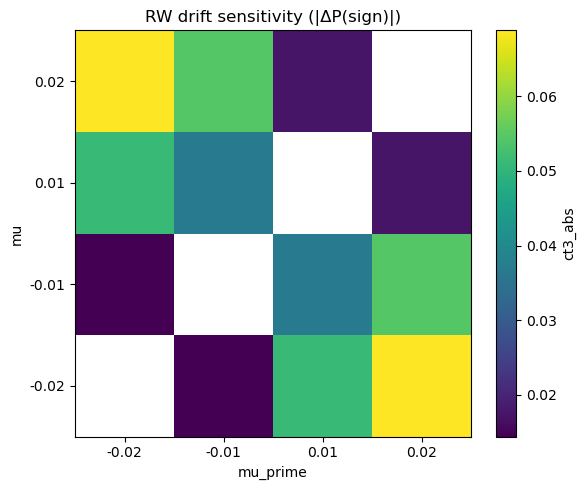

      mu  mu_prime  ct3_signed   ct3_abs   m_theta  m_theta_prime
0  -0.02     -0.01    0.014388  0.014388  0.525180       0.539568
1  -0.02      0.01    0.051387  0.051387  0.525180       0.576567
2  -0.02      0.02    0.068859  0.068859  0.525180       0.594039
3  -0.01     -0.02   -0.014388  0.014388  0.539568       0.525180
4  -0.01      0.01    0.036999  0.036999  0.539568       0.576567
5  -0.01      0.02    0.054471  0.054471  0.539568       0.594039
6   0.01     -0.02   -0.051387  0.051387  0.576567       0.525180
7   0.01     -0.01   -0.036999  0.036999  0.576567       0.539568
8   0.01      0.02    0.017472  0.017472  0.576567       0.594039
9   0.02     -0.02   -0.068859  0.068859  0.594039       0.525180
10  0.02     -0.01   -0.054471  0.054471  0.594039       0.539568
11  0.02      0.01   -0.017472  0.017472  0.594039       0.576567
Plotting CT3 heatmap and table from artifacts/ct3/ar1_phi.csv...


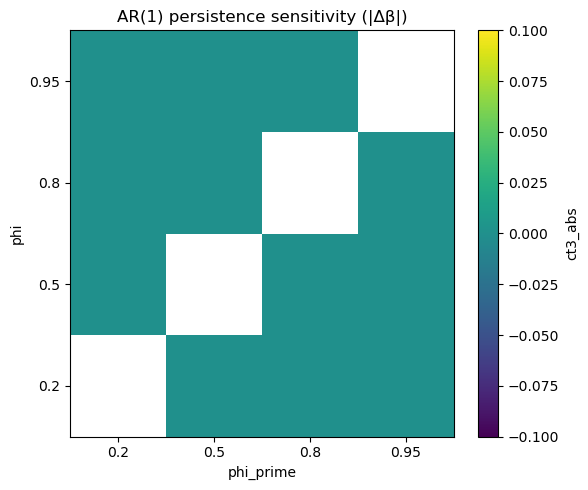

     phi  phi_prime  ct3_signed  ct3_abs   m_theta  m_theta_prime
0   0.20       0.50         0.0      0.0  0.184784       0.184784
1   0.20       0.80         0.0      0.0  0.184784       0.184784
2   0.20       0.95         0.0      0.0  0.184784       0.184784
3   0.50       0.20         0.0      0.0  0.184784       0.184784
4   0.50       0.80         0.0      0.0  0.184784       0.184784
5   0.50       0.95         0.0      0.0  0.184784       0.184784
6   0.80       0.20         0.0      0.0  0.184784       0.184784
7   0.80       0.50         0.0      0.0  0.184784       0.184784
8   0.80       0.95         0.0      0.0  0.184784       0.184784
9   0.95       0.20         0.0      0.0  0.184784       0.184784
10  0.95       0.50         0.0      0.0  0.184784       0.184784
11  0.95       0.80         0.0      0.0  0.184784       0.184784
Plotting CT3 heatmap and table from artifacts/ct3/harmonic_omega_w1.csv...


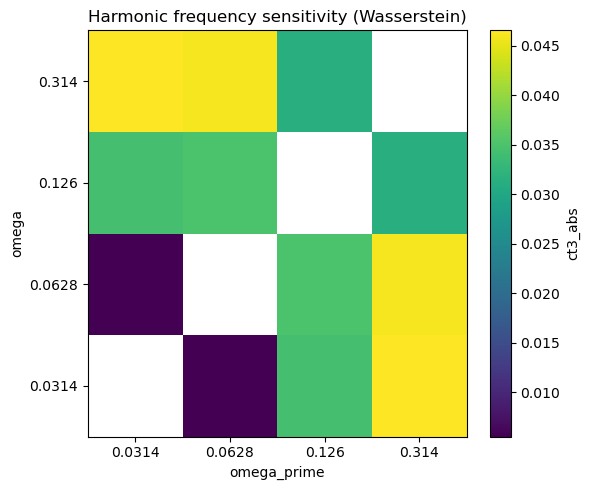

       omega  omega_prime  ct3_signed   ct3_abs  divergence
0   0.031416     0.062832         NaN  0.005515    0.005515
1   0.031416     0.125664         NaN  0.034469    0.034469
2   0.031416     0.314159         NaN  0.046535    0.046535
3   0.062832     0.031416         NaN  0.005515    0.005515
4   0.062832     0.125664         NaN  0.034897    0.034897
5   0.062832     0.314159         NaN  0.046028    0.046028
6   0.125664     0.031416         NaN  0.034469    0.034469
7   0.125664     0.062832         NaN  0.034897    0.034897
8   0.125664     0.314159         NaN  0.031231    0.031231
9   0.314159     0.031416         NaN  0.046535    0.046535
10  0.314159     0.062832         NaN  0.046028    0.046028
11  0.314159     0.125664         NaN  0.031231    0.031231


In [7]:
plot_ct3_heatmap(
    "artifacts/ct3/rw_drift_mu.csv",
    value_col="ct3_abs",
    title="RW drift sensitivity (|ΔP(sign)|)",
)

plot_ct3_heatmap(
    "artifacts/ct3/ar1_phi.csv",
    value_col="ct3_abs",
    title="AR(1) persistence sensitivity (|Δβ|)",
)

plot_ct3_heatmap(
    "artifacts/ct3/harmonic_omega_w1.csv",
    value_col="ct3_abs",
    title="Harmonic frequency sensitivity (Wasserstein)",
)
